In [65]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [66]:
df = pd.read_csv('data/hospital_readmissions.csv')
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [67]:
df['glucose_test'].value_counts()

glucose_test
no        23625
normal      689
high        686
Name: count, dtype: int64

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [69]:
df.dtypes

age                  object
time_in_hospital      int64
n_lab_procedures      int64
n_procedures          int64
n_medications         int64
n_outpatient          int64
n_inpatient           int64
n_emergency           int64
medical_specialty    object
diag_1               object
diag_2               object
diag_3               object
glucose_test         object
A1Ctest              object
change               object
diabetes_med         object
readmitted           object
dtype: object

In [70]:
df.columns

Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

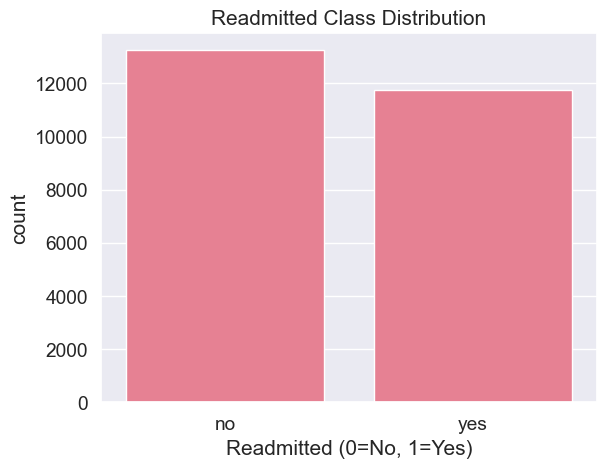

In [71]:

sns.countplot(x='readmitted', data=df)
plt.title('Readmitted Class Distribution')
plt.xlabel('Readmitted (0=No, 1=Yes)')
plt.ylabel('count')
plt.show()

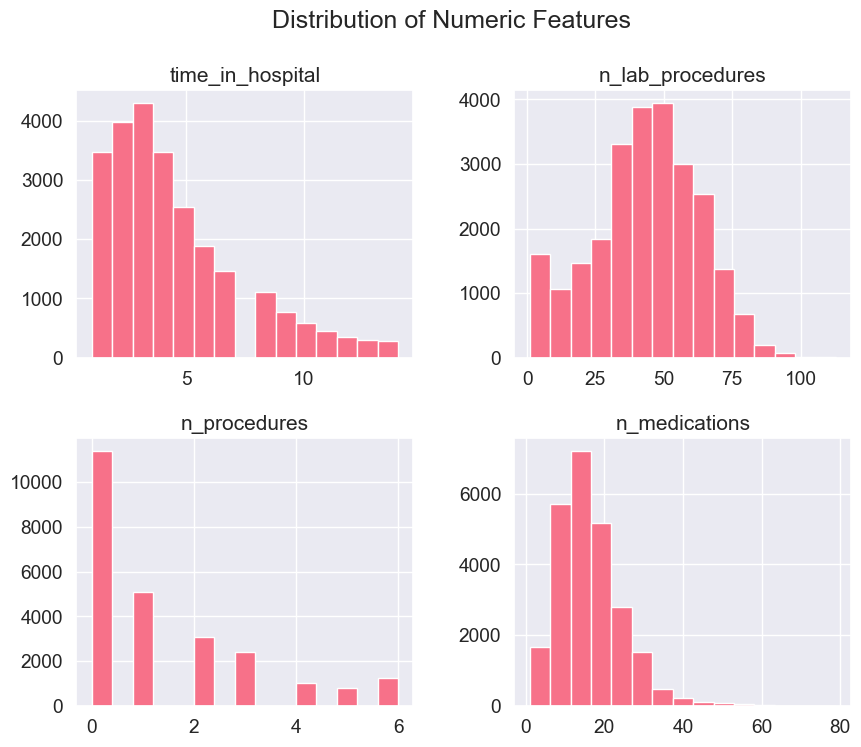

In [72]:
# Histograms for numeric features
numeric_features = ['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications']
df[numeric_features].hist(figsize=(10,8), bins=15)
plt.figsize=(12,10)

plt.suptitle('Distribution of Numeric Features')
plt.show()

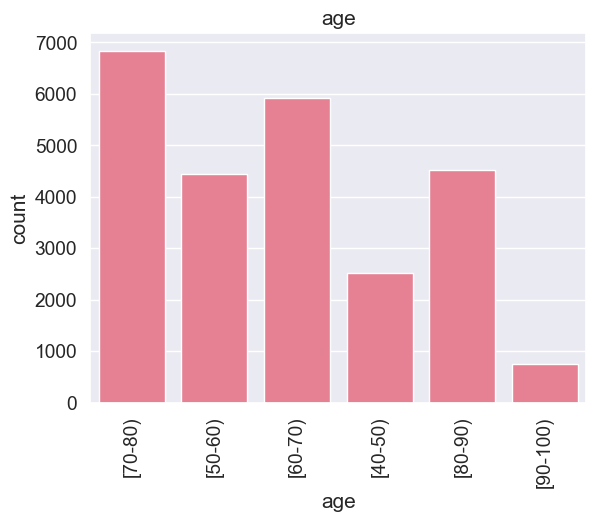

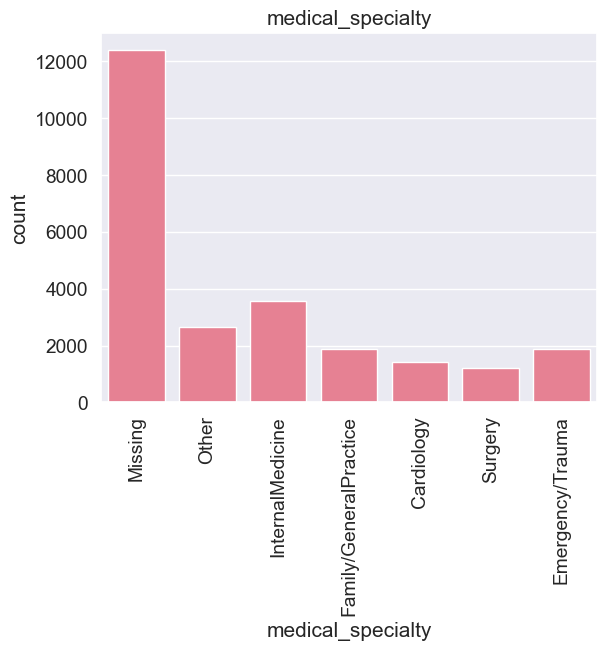

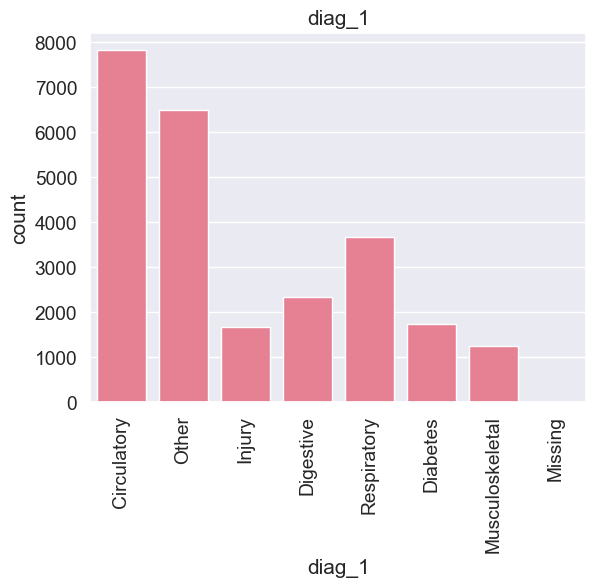

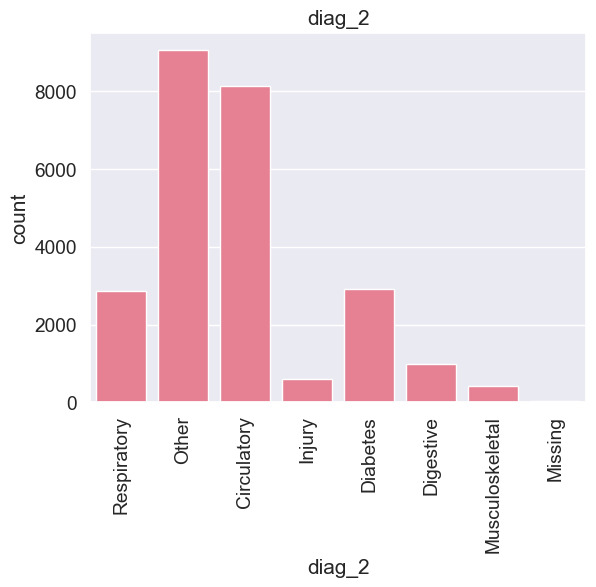

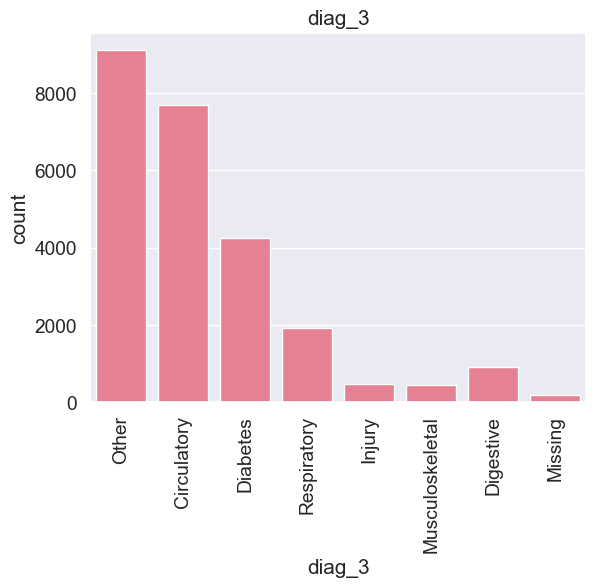

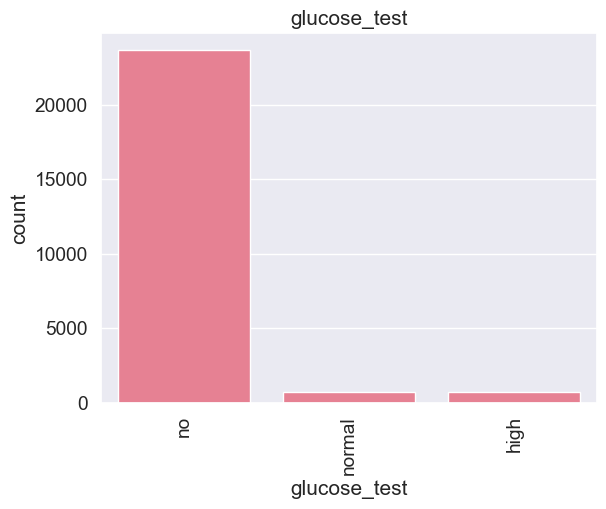

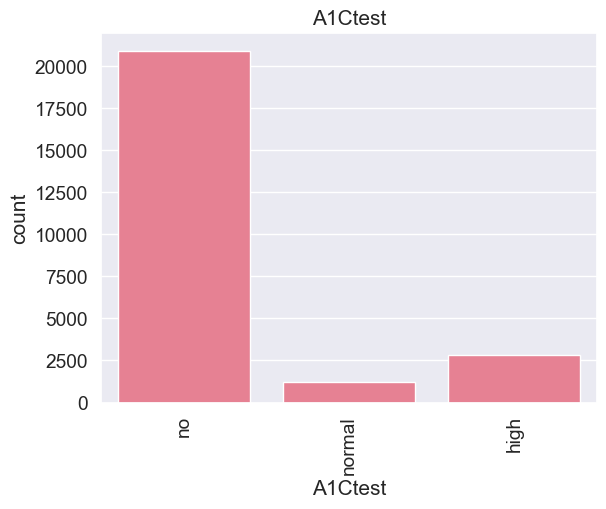

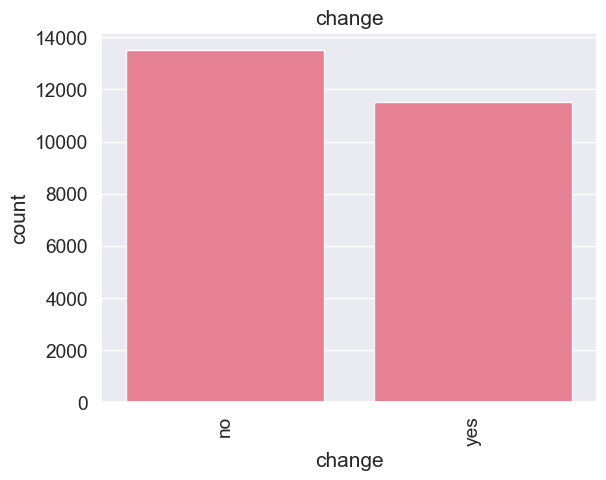

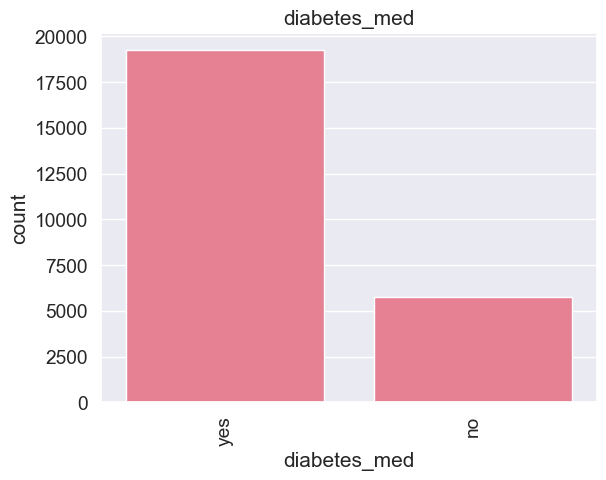

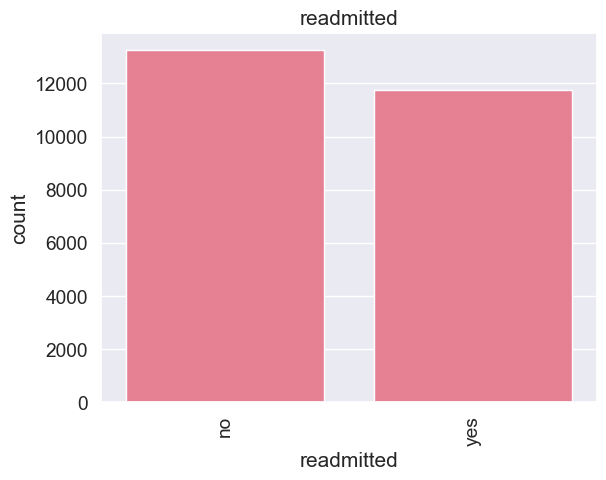

In [73]:


columns = ['age','medical_specialty','diag_1','diag_2','diag_3','glucose_test','A1Ctest','change','diabetes_med','readmitted']

sns.set(style='darkgrid',font_scale=1.25)
sns.set_palette('husl',3)

def plot_cat_count():
    for c in columns:
        sns.countplot(x=c, data=df)
        plt.title(c)
        plt.xticks(rotation=90)
        plt.show()
        
plot_cat_count()

In [74]:
from sklearn.utils import resample

# -------- Balance glucose_test --------
df_no = df[df['glucose_test'] == 'no']
df_normal = df[df['glucose_test'] == 'normal']
df_high = df[df['glucose_test'] == 'high']

# Limit oversampling to 70% of 'no' count
target_size = int(len(df_no) * 0.7)

df_normal_up = resample(df_normal, replace=True, n_samples=target_size, random_state=42)
df_high_up   = resample(df_high,   replace=True, n_samples=target_size, random_state=42)

df = pd.concat([df_no, df_normal_up, df_high_up])

In [75]:
# -------- Balance A1Ctest --------
df_no = df[df['A1Ctest'] == 'no']
df_gt7 = df[df['A1Ctest'] == 'normal']
df_gt8 = df[df['A1Ctest'] == 'high']

# Limit oversampling to 50% of 'no' count
target_size = int(len(df_no) * 0.5)

df_gt7_up = resample(df_gt7, replace=True, n_samples=target_size, random_state=42)
df_gt8_up = resample(df_gt8, replace=True, n_samples=target_size, random_state=42)

df = pd.concat([df_no, df_gt7_up, df_gt8_up]).reset_index(drop=True)

In [76]:
from sklearn.utils import resample
import pandas as pd

# Split into classes
df_missing = df[df['medical_specialty'] == 'Missing']
df_others = df[df['medical_specialty'] != 'Missing']

balanced_dfs = []

# Target size: 50% of Missing count
target_size = int(len(df_missing) * 0.5)

for label in df['medical_specialty'].unique():
    subset = df[df['medical_specialty'] == label]
    if label == "Missing":
        balanced_dfs.append(subset)  # keep Missing as it is
    else:
        if len(subset) < target_size:
            subset_up = resample(subset, replace=True, n_samples=target_size, random_state=42)
            balanced_dfs.append(subset_up)
        else:
            balanced_dfs.append(subset)

# Combine back and overwrite original df
df = pd.concat(balanced_dfs).reset_index(drop=True)

print(df['medical_specialty'].value_counts())


medical_specialty
Missing                   50242
Other                     25121
InternalMedicine          25121
Family/GeneralPractice    25121
Surgery                   25121
Cardiology                25121
Emergency/Trauma          25121
Name: count, dtype: int64


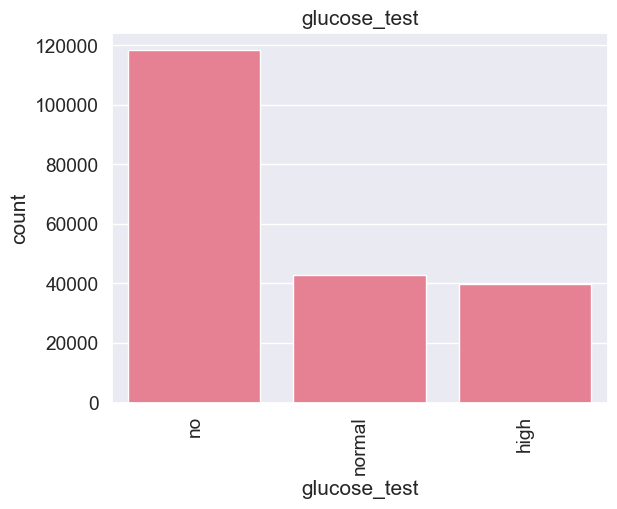

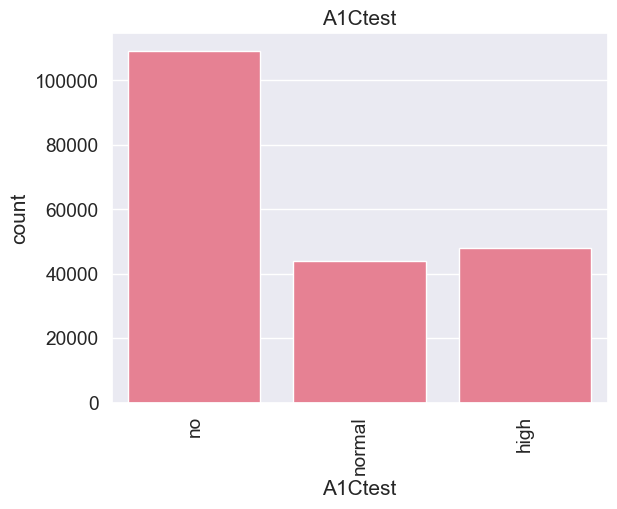

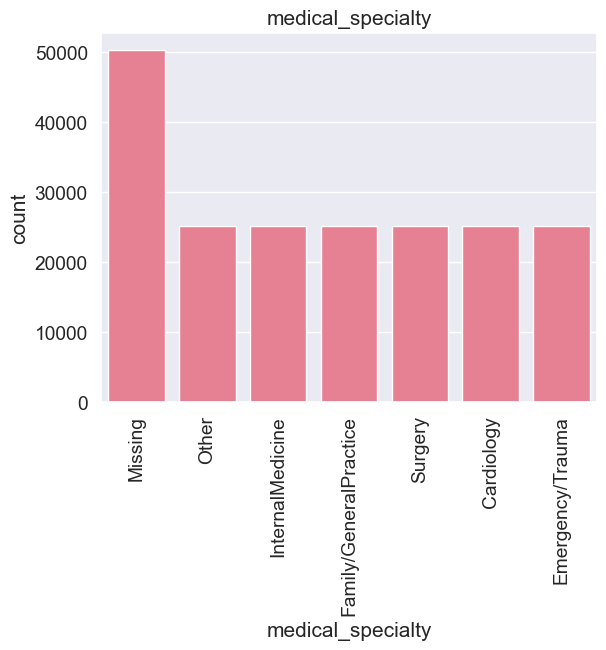

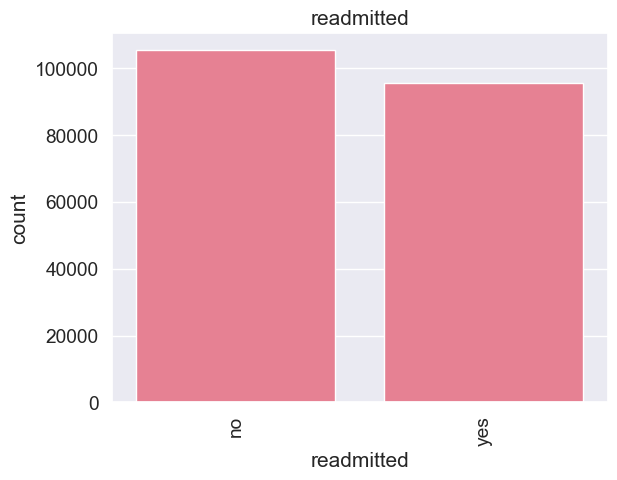

In [77]:

columns = ['glucose_test','A1Ctest','medical_specialty','readmitted']

sns.set(style='darkgrid',font_scale=1.25)
sns.set_palette('husl',3)

def plot_cat_count():
    for c in columns:
        sns.countplot(x=c, data=df)
        plt.title(c)
        plt.xticks(rotation=90)
        plt.show()
        
plot_cat_count()

In [78]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_pie(df, column):
    cat_counts = df[column].value_counts()
    plt.figure(figsize=(8, 8))

    # Generate as many distinct colors as categories
    colors = cm.tab20(np.linspace(0, 1, len(cat_counts)))

    wedges, texts, autotexts = plt.pie(
        cat_counts,
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.8,
        colors=colors
    )

    for a in autotexts:
        a.set_fontsize(10)

    plt.legend(
        wedges,
        cat_counts.index,
        title=f"{column} categories",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.title(f"{column} Distribution")
    plt.tight_layout()
    plt.show()




In [79]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['age', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']
label_encoders = {col: LabelEncoder() for col in categorical_cols}

for col,le in label_encoders.items():
  df[col] = le.fit_transform(df[col].astype(str))

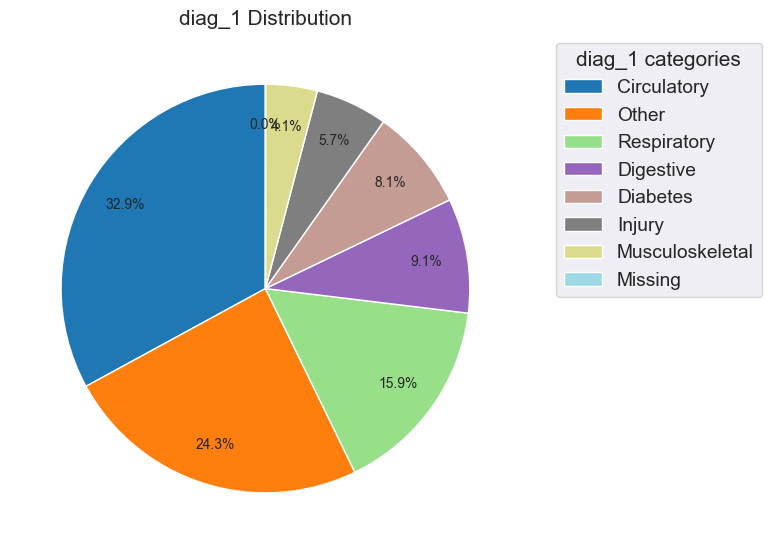

In [80]:
plot_pie(df, 'diag_1')

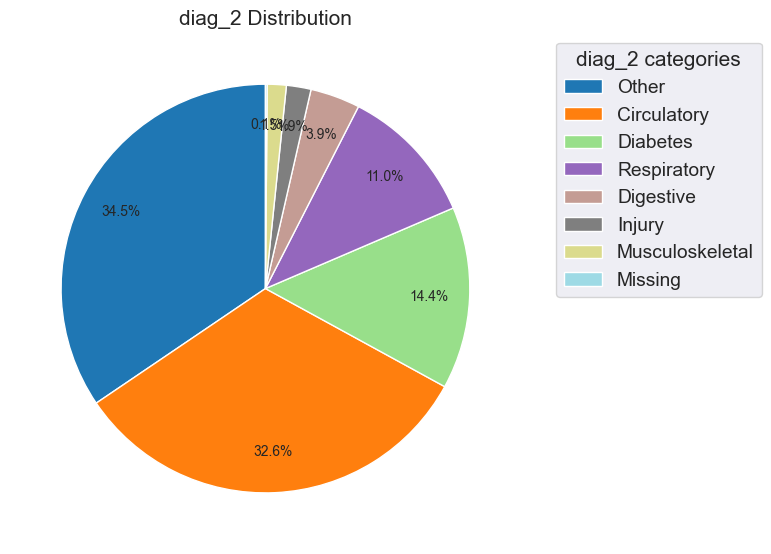

In [81]:
plot_pie(df, 'diag_2')

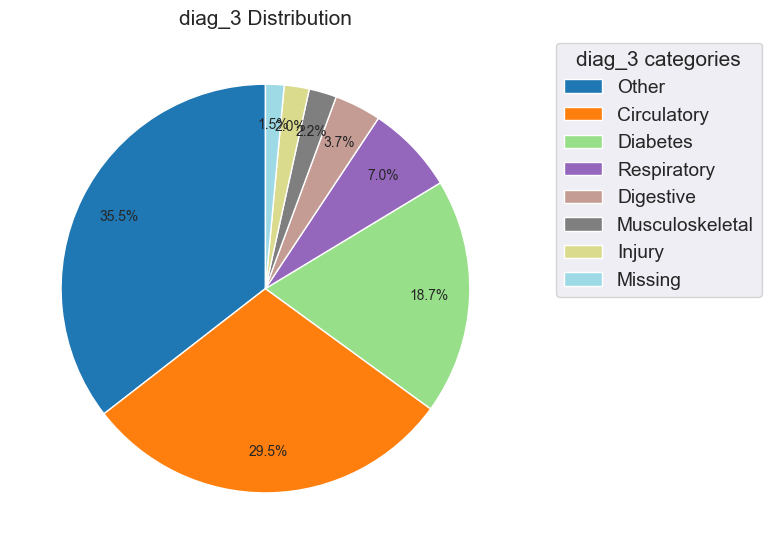

In [82]:
plot_pie(df, 'diag_3')

In [83]:
df.head(10)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,3,8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,1,1,0,1,0
1,1,5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,1,1,1,1,1
2,3,2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,1,1,1,1,1
3,0,2,51,0,10,0,0,0,Missing,Other,Other,Other,1,1,0,0,1
4,3,1,35,0,7,0,0,0,Missing,Injury,Injury,Injury,1,1,1,1,0
5,4,8,52,0,20,0,0,0,Missing,Other,Circulatory,Other,1,1,1,1,1
6,1,1,9,0,11,0,0,0,Missing,Respiratory,Circulatory,Circulatory,1,1,0,0,0
7,2,2,16,3,16,0,0,0,Missing,Circulatory,Diabetes,Other,1,1,0,0,0
8,3,3,69,1,13,0,0,0,Missing,Circulatory,Circulatory,Diabetes,1,1,0,1,1
9,1,4,37,2,15,0,0,0,Missing,Digestive,Digestive,Respiratory,1,1,0,0,0


In [84]:
threshold = 0.02  

# Calculate frequency of each category
freq = df["medical_specialty"].value_counts(normalize=True)

# Categories to keep
common_cats = freq[freq >= threshold].index

# Replace rare categories with "Other"
df["medical_specialty"] = df["medical_specialty"].apply(lambda x: x if x in common_cats else "Other")

In [85]:
df

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,3,8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,1,1,0,1,0
1,1,5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,1,1,1,1,1
2,3,2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,1,1,1,1,1
3,0,2,51,0,10,0,0,0,Missing,Other,Other,Other,1,1,0,0,1
4,3,1,35,0,7,0,0,0,Missing,Injury,Injury,Injury,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200963,4,5,79,3,31,0,0,2,Emergency/Trauma,Circulatory,Circulatory,Respiratory,1,0,1,1,1
200964,0,2,44,6,20,0,0,0,Emergency/Trauma,Circulatory,Circulatory,Circulatory,1,0,1,1,0
200965,4,7,1,5,3,0,0,0,Emergency/Trauma,Other,Digestive,Diabetes,1,1,0,1,0
200966,2,7,54,4,22,0,0,0,Emergency/Trauma,Digestive,Circulatory,Circulatory,1,0,1,1,0


In [86]:
df["total_visits"] = df["n_outpatient"] + df["n_inpatient"] + df["n_emergency"]

df["high_risk"] = np.where((df["A1Ctest"] == "High") | (df["glucose_test"] == "High"), 1, 0)

In [87]:
def severity(days):
    if days <= 3:
        return "low"
    elif days <= 7:
        return "medium"
    else:
        return "high"

df["severity"] = df["time_in_hospital"].apply(severity)

In [88]:
df['severity'] = df['severity'].replace({'low':0,'medium':1,'high':2})
                                          

C:\Users\Kannadasan\AppData\Local\Temp\ipykernel_16788\379654066.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['severity'] = df['severity'].replace({'low':0,'medium':1,'high':2})


In [89]:
diag_cols = ['diag_1', 'diag_2', 'diag_3']


categories = pd.unique(df[diag_cols].values.ravel())

one_hot = pd.DataFrame(0, index=df.index, columns=categories)

for col in diag_cols:
    one_hot = one_hot | pd.get_dummies(df[col]).reindex(columns=categories, fill_value=0)

one_hot = one_hot.astype(int)

df_dropped = df.drop(columns=diag_cols)

insert_at = 9

left = df_dropped.iloc[:, :insert_at]
right = df_dropped.iloc[:, insert_at:]


df_final = pd.concat([left, one_hot, right], axis=1)


print(df_final.head())

   age  time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
0    3                 8                72             1             18   
1    1                 5                45             0             18   
2    3                 2                36             0             12   
3    0                 2                51             0             10   
4    3                 1                35             0              7   

   n_outpatient  n_inpatient  n_emergency medical_specialty  Circulatory  ...  \
0             2            0            0           Missing            1  ...   
1             0            0            0           Missing            1  ...   
2             1            0            0           Missing            1  ...   
3             0            0            0           Missing            0  ...   
4             0            0            0           Missing            0  ...   

   Musculoskeletal  Missing  glucose_test  A1Ctest  change  di

In [90]:
df=df_final

In [91]:
categorical_cols_2 = ['medical_specialty']
label_encoders_2 = {col: LabelEncoder() for col in categorical_cols_2}

for col2,le in label_encoders_2.items():
  df[col2] = le.fit_transform(df[col2].astype(str))

In [92]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,Circulatory,...,Musculoskeletal,Missing,glucose_test,A1Ctest,change,diabetes_med,readmitted,total_visits,high_risk,severity
0,3,8,72,1,18,2,0,0,4,1,...,0,0,1,1,0,1,0,2,0,2
1,1,5,45,0,18,0,0,0,4,1,...,0,0,1,1,1,1,1,0,0,1
2,3,2,36,0,12,1,0,0,4,1,...,0,0,1,1,1,1,1,1,0,0
3,0,2,51,0,10,0,0,0,4,0,...,0,0,1,1,0,0,1,0,0,0
4,3,1,35,0,7,0,0,0,4,0,...,0,0,1,1,1,1,0,0,0,0


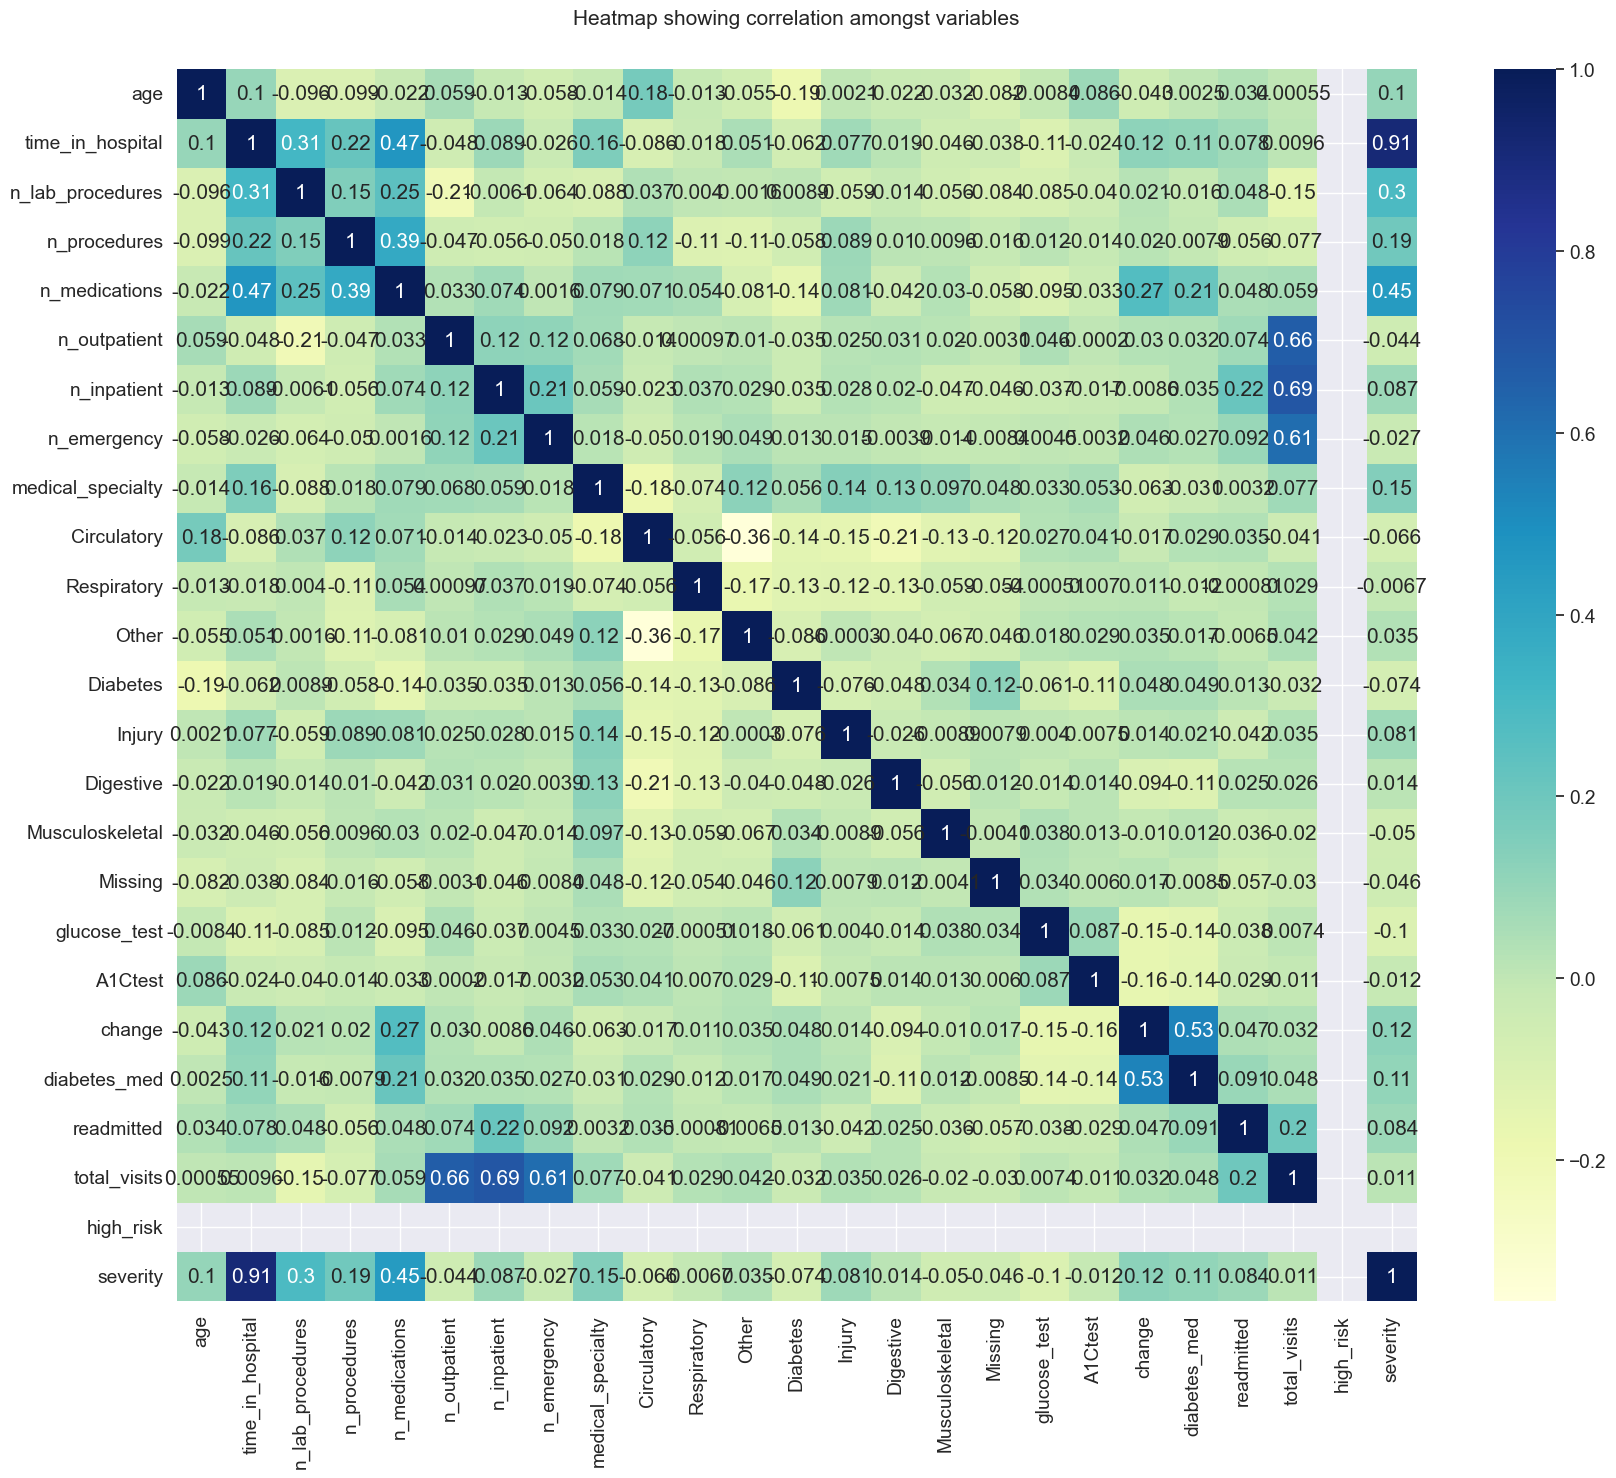

In [93]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), cmap='YlGnBu', fmt='.2g', annot=True)

plt.title('Heatmap showing correlation amongst variables',y=1.03)
plt.show()

In [94]:
X = df.drop(columns=["readmitted"])   # all other columns as features
y = df["readmitted"]

print('X shape:', X.shape)
#print('X_features:',X_features.shape)
print('y shape:', y.shape)

X shape: (200968, 24)
y shape: (200968,)


In [95]:
df['readmitted'].value_counts()

readmitted
0    105357
1     95611
Name: count, dtype: int64

In [96]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,Circulatory,...,Musculoskeletal,Missing,glucose_test,A1Ctest,change,diabetes_med,readmitted,total_visits,high_risk,severity
0,3,8,72,1,18,2,0,0,4,1,...,0,0,1,1,0,1,0,2,0,2
1,1,5,45,0,18,0,0,0,4,1,...,0,0,1,1,1,1,1,0,0,1
2,3,2,36,0,12,1,0,0,4,1,...,0,0,1,1,1,1,1,1,0,0
3,0,2,51,0,10,0,0,0,4,0,...,0,0,1,1,0,0,1,0,0,0
4,3,1,35,0,7,0,0,0,4,0,...,0,0,1,1,1,1,0,0,0,0


In [97]:
df.drop(['n_outpatient', 'n_inpatient', 'n_emergency', 'time_in_hospital'], 
        axis=1, inplace=True)


In [98]:
### Splitting the Data

from sklearn.model_selection import train_test_split

X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [99]:
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [100]:
### Baseline Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, pair_confusion_matrix


log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.72      0.66     21046
           1       0.61      0.48      0.54     19148

    accuracy                           0.60     40194
   macro avg       0.61      0.60      0.60     40194
weighted avg       0.60      0.60      0.60     40194

ROC-AUC: 0.5986830036232669


c:\Users\Kannadasan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
### Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     21046
           1       0.98      0.97      0.97     19148

    accuracy                           0.97     40194
   macro avg       0.97      0.97      0.97     40194
weighted avg       0.97      0.97      0.97     40194

ROC-AUC Score: 0.97441544331921


In [102]:
# Adjusting Hyperparameters for the Random Forest Classifier

rf_tuned = RandomForestClassifier(
    bootstrap=True,
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)

#Training the model
rf_tuned.fit(X_train, y_train)


#Predicting on the test set
y_pred_tuned = rf_tuned.predict(X_test)
y_proba_tuned = rf_tuned.predict_proba(X_test)[:,1]

#Evaluate Performance
print("Classification Report:\n", classification_report(y_test, y_pred_tuned))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_tuned))

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.82     21046
           1       0.83      0.75      0.79     19148

    accuracy                           0.81     40194
   macro avg       0.81      0.80      0.81     40194
weighted avg       0.81      0.81      0.81     40194

ROC-AUC Score: 0.8048524662749442


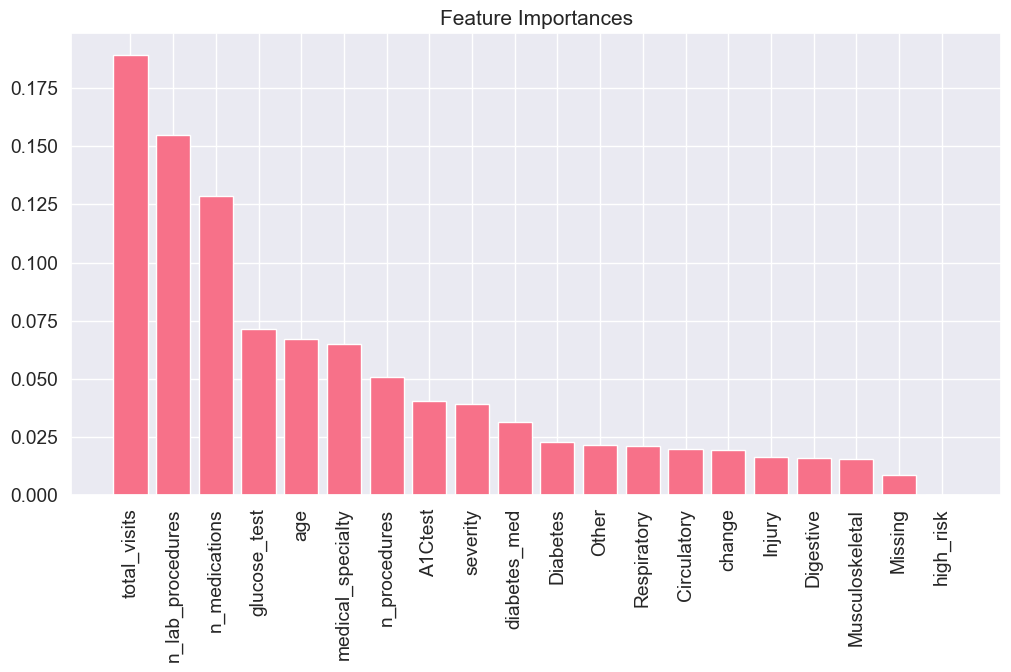

In [103]:
### Feature Importance

importances = rf_tuned.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.show()

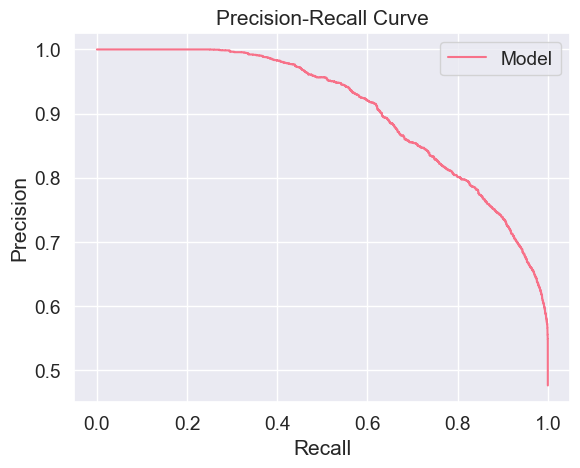

In [104]:
## Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, rf_tuned.predict_proba(X_test)[:,1])
plt.plot(recall, precision, label='Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [105]:
### XGBoost Implementation

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

#Evaluation
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost ROC-AUC Score:", roc_auc_score(y_test, y_proba_xgb))

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96     21046
           1       0.97      0.95      0.96     19148

    accuracy                           0.96     40194
   macro avg       0.96      0.96      0.96     40194
weighted avg       0.96      0.96      0.96     40194

XGBoost ROC-AUC Score: 0.9943790734257811


In [106]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

#Predictions
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

#Evaluation
print("LigthGBM Classification Report:\n", classification_report(y_test, y_pred_lgbm))
print("LightGBM ROC-AUC Score:", roc_auc_score(y_test, y_proba_lgbm))

[LightGBM] [Info] Number of positive: 76463, number of negative: 84311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 254
[LightGBM] [Info] Number of data points in the train set: 160774, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475593 -> initscore=-0.097705
[LightGBM] [Info] Start training from score -0.097705
LigthGBM Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86     21046
           1       0.87      0.80      0.83     19148

    accuracy                           0.85     40194
   macro avg       0.85      0.85      0.85     40194
weighted avg       0.85      0.85      0.85     40194

LightGBM ROC-AUC Score: 0.934007970017867


In [107]:
results = {
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "ROC-AUC Score": [roc_auc_score(y_test, rf_tuned.predict_proba(X_test)[:, 1]),
                roc_auc_score(y_test, y_proba_xgb),
                roc_auc_score(y_test, y_proba_lgbm)]
}

results_df = pd.DataFrame(results)
print(results_df)

           Model  ROC-AUC Score
0  Random Forest       0.907357
1        XGBoost       0.994379
2       LightGBM       0.934008


In [108]:
import tensorflow as tf
# Build model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/20


c:\Users\Kannadasan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6111 - loss: 0.6552 - val_accuracy: 0.6234 - val_loss: 0.6582
Epoch 2/20
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.6509 - loss: 0.6194 - val_accuracy: 0.6736 - val_loss: 0.5976
Epoch 3/20
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6824 - loss: 0.5877 - val_accuracy: 0.6850 - val_loss: 0.5785
Epoch 4/20
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7051 - loss: 0.5575 - val_accuracy: 0.7059 - val_loss: 0.5549
Epoch 5/20
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7250 - loss: 0.5292 - val_accuracy: 0.7312 - val_loss: 0.5198
Epoch 6/20
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7380 - loss: 0.5077 - val_accuracy: 0.7342 - val_loss: 0.5040
Epoch 7/20
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7497 - loss: 0.4905 - val_accuracy: 0.7476 - val_loss: 0.4888
Epoch 8/20
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.7591 - loss: 0.4765 - val

In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


1257/1257 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Testing Accuracy: 0.7977558839627805
Precision: 0.7970561276756348
Recall: 0.7720388552329225


1257/1257 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Best Model Summary:
Model             XGBoost
Accuracy         0.960118
Precision (0)    0.955532
Recall (0)       0.968925
F1-Score (0)     0.962182
Precision (1)    0.965311
Recall (1)       0.950439
F1-Score (1)     0.957817
ROC-AUC          0.994379
Name: 2, dtype: object

Complete Results Table:


,Model,Accuracy,Precision (0),Recall (0),F1-Score (0),Precision (1),Recall (1),F1-Score (1),ROC-AUC
0,Logistic Regression,0.604369,0.602372,0.719092,0.655577,0.607697,0.478274,0.535274,0.648927
1,Random Forest,0.807583,0.789391,0.862682,0.824411,0.831918,0.747023,0.787188,0.907357
2,XGBoost,0.960118,0.955532,0.968925,0.962182,0.965311,0.950439,0.957817,0.994379
3,LightGBM,0.847291,0.828863,0.892664,0.859581,0.871120,0.797420,0.832643,0.934008
4,Neural Network,0.797756,0.798355,0.821154,0.809594,0.797056,0.772039,0.784348,0.889928


C:\Users\Kannadasan\AppData\Local\Temp\ipykernel_16788\3542250824.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="ROC-AUC", palette="viridis")


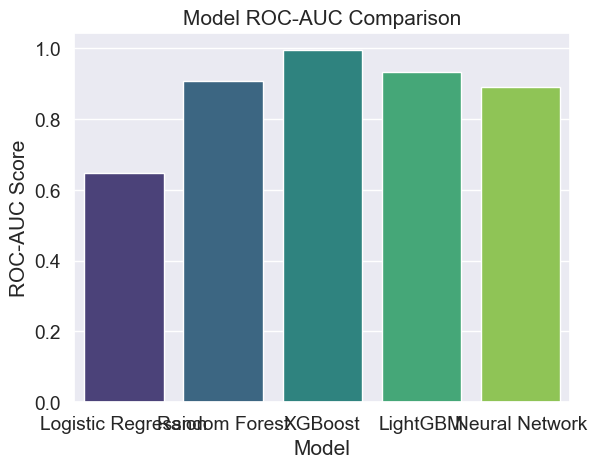

In [110]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import numpy as np

# Define a function to calculate evaluation metrics
def evaluate_model(model, X_test, y_test, model_name, is_nn=False):
   
    if is_nn:  
        # For Neural Network (Keras)
        y_prob = model.predict(X_test).flatten()
        y_pred = (y_prob > 0.5).astype(int)
    else:  
        # For sklearn models
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else "N/A"

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (0)": metrics["0"]["precision"],
        "Recall (0)": metrics["0"]["recall"],
        "F1-Score (0)": metrics["0"]["f1-score"],
        "Precision (1)": metrics["1"]["precision"],
        "Recall (1)": metrics["1"]["recall"],
        "F1-Score (1)": metrics["1"]["f1-score"],
        "ROC-AUC": roc_auc
    }

# ------------------------
# Evaluate all models
results = []

# Logistic Regression
results.append(evaluate_model(log_reg, X_test, y_test, "Logistic Regression"))

# Random Forest
results.append(evaluate_model(rf_tuned, X_test, y_test, "Random Forest"))

# XGBoost
results.append(evaluate_model(xgb, X_test, y_test, "XGBoost"))

# LightGBM
results.append(evaluate_model(lgbm, X_test, y_test, "LightGBM"))

# Neural Network (Keras example)
results.append(evaluate_model(model, X_test, y_test, "Neural Network", is_nn=True))

# Convert results to a DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

# Highlight the best-performing model
best_model = results_df.loc[results_df["ROC-AUC"].idxmax()]
print("Best Model Summary:")
print(best_model)

# Display the full results table
import seaborn as sns
import matplotlib.pyplot as plt

print("\nComplete Results Table:")
display(results_df)

# Plot the metrics for visualization
sns.barplot(data=results_df, x="Model", y="ROC-AUC", palette="viridis")
plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC Score")
plt.show()
